In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE, SelectKBest, chi2
from sklearn.model_selection import cross_val_score
from pandas.core.common import random_state
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [3]:
data = pd.read_csv("/content/drive/MyDrive/Hj/Raw data(GIS (Non zero)).csv")

In [4]:
data.head(5)

,Sample point,Name,Date,Time,Temperature (Deg.C),pH,Redox (mV),DO (mg/L),Salinity (g/L),Conductivity (mS/cm),Latitude,Longitude
0,2,Police plaza boat stand,3/16/2022,16:22:21,28.782,7.861,126.71,2.891,0.161,0.322,23.772318,90.415756
1,2,Police plaza boat stand,3/16/2022,16:22:27,28.729,7.784,135.85,2.422,0.155,0.310,23.772318,90.415756
2,2,Police plaza boat stand,3/16/2022,16:22:32,28.719,7.784,136.91,2.038,0.149,0.299,23.772318,90.415756
3,2,Police plaza boat stand,3/16/2022,16:22:37,28.681,7.704,140.78,1.662,0.143,0.286,23.772318,90.415756
4,2,Police plaza boat stand,3/16/2022,16:22:42,28.682,7.727,139.37,1.362,0.137,0.275,23.772318,90.415756


In [5]:
data.tail(5)

,Sample point,Name,Date,Time,Temperature (Deg.C),pH,Redox (mV),DO (mg/L),Salinity (g/L),Conductivity (mS/cm),Latitude,Longitude
306,8,FDC boat stand hatirjheel,3/16/2022,18:37:42,27.093,7.548,125.34,2.000,0.191,0.373,23.755163,90.402702
307,8,FDC boat stand hatirjheel,3/16/2022,18:37:47,27.088,7.547,125.32,1.980,0.191,0.373,23.755163,90.402702
308,8,FDC boat stand hatirjheel,3/16/2022,18:37:52,27.097,7.527,126.61,1.924,0.191,0.373,23.755163,90.402702
309,8,FDC boat stand hatirjheel,3/16/2022,18:37:57,27.095,7.544,125.74,1.904,0.191,0.373,23.755163,90.402702
310,8,FDC boat stand hatirjheel,3/16/2022,18:38:02,27.097,7.535,126.21,1.882,0.192,0.374,23.755163,90.402702


In [6]:
data.shape

(311, 12)

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Sample point,311.0,4.951768,1.826575,2.000000,4.000000,5.000000,7.000000,8.000000
Temperature (Deg.C),311.0,27.856479,0.629656,26.220000,27.432000,28.147000,28.269500,28.987000
pH,311.0,7.716354,0.140364,7.368000,7.640000,7.737000,7.796000,7.981000
Redox (mV),311.0,137.003148,28.515645,42.791000,125.235000,136.740000,160.930000,182.990000
DO (mg/L),311.0,2.477913,1.348579,0.007000,1.299000,2.465000,3.548000,4.489000
Salinity (g/L),311.0,0.182125,0.028728,0.013000,0.189000,0.191000,0.194000,0.198000
Conductivity (mS/cm),311.0,0.360839,0.057287,0.025000,0.372000,0.377000,0.385000,0.396000
Latitude,311.0,23.764260,0.005518,23.755163,23.757874,23.764591,23.768450,23.772917
Longitude,311.0,90.412651,0.006760,90.402702,90.403694,90.412270,90.419239,90.422104


In [8]:
data.drop(['Sample point','Name','Date','Time'], axis=1, inplace=True)

In [9]:
data.head(5)

,Temperature (Deg.C),pH,Redox (mV),DO (mg/L),Salinity (g/L),Conductivity (mS/cm),Latitude,Longitude
0,28.782,7.861,126.71,2.891,0.161,0.322,23.772318,90.415756
1,28.729,7.784,135.85,2.422,0.155,0.310,23.772318,90.415756
2,28.719,7.784,136.91,2.038,0.149,0.299,23.772318,90.415756
3,28.681,7.704,140.78,1.662,0.143,0.286,23.772318,90.415756
4,28.682,7.727,139.37,1.362,0.137,0.275,23.772318,90.415756


In [10]:
data.tail(5)

,Temperature (Deg.C),pH,Redox (mV),DO (mg/L),Salinity (g/L),Conductivity (mS/cm),Latitude,Longitude
306,27.093,7.548,125.34,2.000,0.191,0.373,23.755163,90.402702
307,27.088,7.547,125.32,1.980,0.191,0.373,23.755163,90.402702
308,27.097,7.527,126.61,1.924,0.191,0.373,23.755163,90.402702
309,27.095,7.544,125.74,1.904,0.191,0.373,23.755163,90.402702
310,27.097,7.535,126.21,1.882,0.192,0.374,23.755163,90.402702


In [11]:
data.isnull().sum()

,0
Temperature (Deg.C),0
pH,0
Redox (mV),0
DO (mg/L),0
Salinity (g/L),0
Conductivity (mS/cm),0
Latitude,0
Longitude,0


In [12]:
print(data.std())

Temperature (Deg.C)      0.629656
pH                       0.140364
Redox (mV)              28.515645
DO (mg/L)                1.348579
Salinity (g/L)           0.028728
Conductivity (mS/cm)     0.057287
Latitude                 0.005518
Longitude                0.006760
dtype: float64


In [13]:
data.corr()

,Temperature (Deg.C),pH,Redox (mV),DO (mg/L),Salinity (g/L),Conductivity (mS/cm),Latitude,Longitude
Temperature (Deg.C),1.000000,0.753755,0.530364,-0.159535,0.216607,0.242742,0.568384,0.469381
pH,0.753755,1.000000,0.774912,0.338439,0.133616,0.141095,0.041431,0.064132
Redox (mV),0.530364,0.774912,1.000000,0.295064,-0.104928,-0.103117,-0.011626,0.114689
DO (mg/L),-0.159535,0.338439,0.295064,1.000000,0.025331,0.022022,-0.589575,-0.565828
Salinity (g/L),0.216607,0.133616,-0.104928,0.025331,1.000000,0.998612,-0.019063,-0.070662
Conductivity (mS/cm),0.242742,0.141095,-0.103117,0.022022,0.998612,1.000000,0.019373,-0.041544
Latitude,0.568384,0.041431,-0.011626,-0.589575,-0.019063,0.019373,1.000000,0.895859
Longitude,0.469381,0.064132,0.114689,-0.565828,-0.070662,-0.041544,0.895859,1.000000


<Axes: >

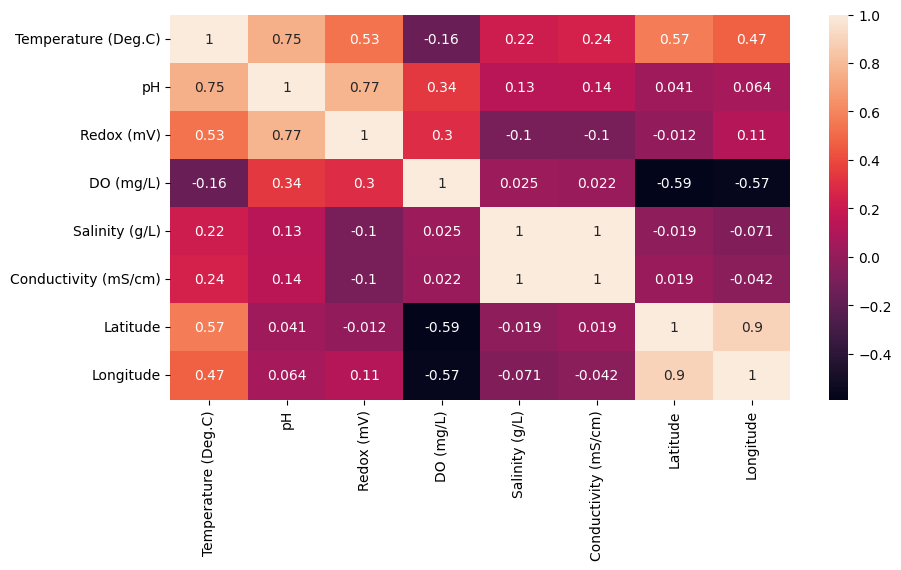

In [14]:
plt.figure(figsize=(10,5))
sns.heatmap(data.corr(), annot=True)



In [15]:
X = data.drop(['DO (mg/L)'], axis=1)
y = data['DO (mg/L)']

In [16]:
from sklearn.feature_selection import SelectKBest, f_regression

# Select top 21 best features based on f_regression
k_best = SelectKBest(score_func=f_regression, k=21)
X_cfs = k_best.fit_transform(X, y)


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=21 is greater than n_features=7. All the features will be returned.
  warnings.warn(


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30,random_state=42)

In [18]:
X_train.shape

(217, 7)

In [19]:
X_test.shape

(94, 7)

In [20]:
y_test.shape

(94,)

In [21]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

In [22]:
X_test.shape

(94, 7)

In [23]:
y_test.shape

(94,)

In [27]:
models=[]

In [28]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize the Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
model_dt = dt.fit(X_train, y_train)
models.append(model_dt)

# Predictions
prediction_dt = model_dt.predict(X_test)

# Evaluation metrics
mse_dt = mean_squared_error(y_test, prediction_dt)
rmse_dt = np.sqrt(mse_dt)
mae_dt = mean_absolute_error(y_test, prediction_dt)
r2_dt = r2_score(y_test, prediction_dt)

print("Decision Tree Regression:")
print("Mean Squared Error (MSE):", round(mse_dt, 4))
print("Root Mean Squared Error (RMSE):", round(rmse_dt, 4))
print("Mean Absolute Error (MAE):", round(mae_dt, 4))
print("R² Score:", round(r2_dt, 4))


Decision Tree Regression:
Mean Squared Error (MSE): 0.0783
Root Mean Squared Error (RMSE): 0.2798
Mean Absolute Error (MAE): 0.1401
R² Score: 0.9566


In [29]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Create and train the K-Nearest Neighbors Regressor
knn = KNeighborsRegressor(n_neighbors=5)
model_knn = knn.fit(X_train, y_train)
models.append(model_knn)

# Predictions
prediction_knn = model_knn.predict(X_test)

# Evaluation metrics
mse_knn = mean_squared_error(y_test, prediction_knn)
rmse_knn = np.sqrt(mse_knn)
mae_knn = mean_absolute_error(y_test, prediction_knn)
r2_knn = r2_score(y_test, prediction_knn)

print("K-Nearest Neighbors Regression:")
print("Mean Squared Error (MSE):", round(mse_knn, 4))
print("Root Mean Squared Error (RMSE):", round(rmse_knn, 4))
print("Mean Absolute Error (MAE):", round(mae_knn, 4))
print("R² Score:", round(r2_knn, 4))


K-Nearest Neighbors Regression:
Mean Squared Error (MSE): 0.0686
Root Mean Squared Error (RMSE): 0.2618
Mean Absolute Error (MAE): 0.1398
R² Score: 0.962


In [30]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Gradient Boosting Regressor model
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Fit the model to the training data
model_gbr = gbr.fit(X_train, y_train)
models.append(model_gbr)

# Make predictions on the test set
prediction_gbr = model_gbr.predict(X_test)

# Calculate regression metrics
mse_gbr = mean_squared_error(y_test, prediction_gbr)
r2_gbr = r2_score(y_test, prediction_gbr)

# Print results
print("Gradient Boosting Regression:")
print("Mean Squared Error:", mse_gbr)
print("R-squared:", r2_gbr)


Gradient Boosting Regression:
Mean Squared Error: 0.04214508682230992
R-squared: 0.976662040191007


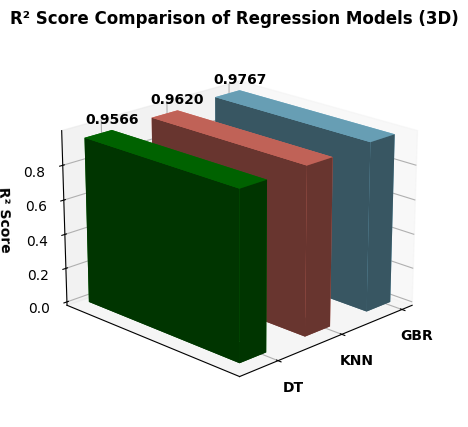

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Regression metrics list (R² scores for different models)
regression_scores = [r2_gbr,r2_knn,r2_dt]

# Names of the algorithms
algo_names = ['GBR','KNN','DT',]

# Define colors for each bar
colors = ['skyblue', 'salmon', 'green']

# Create figure and 3D axis
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

# X positions for bars
x_pos = np.arange(len(algo_names))
y_pos = np.zeros(len(algo_names))  # Single bar depth

# Bar width and depth
width = 0.4
depth = 0.3

# Create 3D bars
bars = ax.bar3d(x_pos, y_pos, np.zeros(len(algo_names)), width, depth, regression_scores, color=colors, shade=True)

# Set labels and title
ax.set_xticks(x_pos)
ax.set_xticklabels(algo_names, fontsize=10, fontweight='bold')
ax.set_yticks([])  # Hide y-axis ticks
ax.set_zlabel("R² Score", fontsize=10, fontweight='bold')
ax.set_title("R² Score Comparison of Regression Models (3D)", fontsize=12, fontweight='bold')

# Annotate bars with scores
for x, z in zip(x_pos, regression_scores):
    ax.text(x, 0, z + 0.02, f"{z:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# Adjust viewing angle
ax.view_init(elev=20, azim=45)  # Elevation and rotation for better visibility

# Show the plot
plt.show()


In [55]:
from sklearn.ensemble import VotingRegressor



# Create the Voting Regressor
voting_regressor = VotingRegressor(estimators=[
    ('dt',models[0]),
    ('knn',models[1]),
    ('gbr',models[2])


] )

In [56]:
# Fit the model
voting_regressor.fit(X_train, y_train)

VotingRegressor(estimators=[('dt', DecisionTreeRegressor(random_state=42)),
                            ('knn', KNeighborsRegressor()),
                            ('gbr',
                             GradientBoostingRegressor(random_state=42))])

In [57]:

prediction_vt=voting_regressor.predict(X_test)


In [65]:
# Evaluation metrics
mse_vt = mean_squared_error(y_test, prediction_vt)
rmse_vt = np.sqrt(mse_vt)
mae_vt = mean_absolute_error(y_test, prediction_vt)
r2_vt = r2_score(y_test, prediction_vt)

print("Gradient Boosting Regression:")
print("Mean Squared Error (MSE):", round(mse_vt, 4))
print("Root Mean Squared Error (RMSE):", round(rmse_vt, 4))
print("Mean Absolute Error (MAE):", round(mae_vt, 4))
print("R² Score:", round(r2_vt, 4))

Gradient Boosting Regression:
Mean Squared Error (MSE): 0.0457
Root Mean Squared Error (RMSE): 0.2137
Mean Absolute Error (MAE): 0.1155
R² Score: 0.9747


In [59]:
from sklearn.ensemble import StackingRegressor
from sklearn.svm import SVR


# Create the stacking Regressor
stacking_regressor = StackingRegressor(estimators=[
    ('dt',models[0]),
    ('knn',models[1]),
    ('gbr',models[2])

],final_estimator=SVR())


In [60]:
# Fit the model
stacking_regressor.fit(X_train, y_train)

StackingRegressor(estimators=[('dt', DecisionTreeRegressor(random_state=42)),
                              ('knn', KNeighborsRegressor()),
                              ('gbr',
                               GradientBoostingRegressor(random_state=42))],
                  final_estimator=SVR())

In [61]:
prediction_st=stacking_regressor.predict(X_test)

In [62]:
# Evaluation metrics
mse_st = mean_squared_error(y_test, prediction_st)
rmse_st = np.sqrt(mse_st)
mae_st = mean_absolute_error(y_test, prediction_st)
r2_st = r2_score(y_test, prediction_st)

print("Gradient Boosting Regression:")
print("Mean Squared Error (MSE):", round(mse_st, 4))
print("Root Mean Squared Error (RMSE):", round(rmse_st, 4))
print("Mean Absolute Error (MAE):", round(mae_st, 4))
print("R² Score:", round(r2_st, 4))

Gradient Boosting Regression:
Mean Squared Error (MSE): 0.0406
Root Mean Squared Error (RMSE): 0.2015
Mean Absolute Error (MAE): 0.1224
R² Score: 0.9775


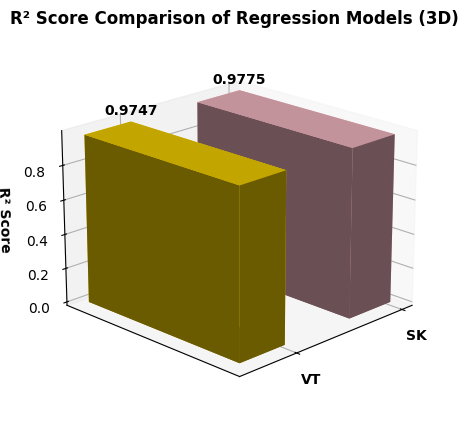

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Regression metrics list (R² scores for different models)
regression_scores = [r2_st,r2_vt]

# Names of the algorithms
algo_names = ['SK','VT',]

# Define colors for each bar
colors = ['pink', 'gold']

# Create figure and 3D axis
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')

# X positions for bars
x_pos = np.arange(len(algo_names))
y_pos = np.zeros(len(algo_names))  # Single bar depth

# Bar width and depth
width = 0.4
depth = 0.3

# Create 3D bars
bars = ax.bar3d(x_pos, y_pos, np.zeros(len(algo_names)), width, depth, regression_scores, color=colors, shade=True)

# Set labels and title
ax.set_xticks(x_pos)
ax.set_xticklabels(algo_names, fontsize=10, fontweight='bold')
ax.set_yticks([])  # Hide y-axis ticks
ax.set_zlabel("R² Score", fontsize=10, fontweight='bold')
ax.set_title("R² Score Comparison of Regression Models (3D)", fontsize=12, fontweight='bold')

# Annotate bars with scores
for x, z in zip(x_pos, regression_scores):
    ax.text(x, 0, z + 0.02, f"{z:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# Adjust viewing angle
ax.view_init(elev=20, azim=45)  # Elevation and rotation for better visibility

# Show the plot
plt.show()


In [68]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf = rf.fit(X_train, y_train)
models.append(model_rf)

# Predictions
prediction_rf = model_rf.predict(X_test)

# Evaluation metrics
mse_rf = mean_squared_error(y_test, prediction_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, prediction_rf)
r2_rf = r2_score(y_test, prediction_rf)

print("Random Forest Regression:")
print("Mean Squared Error (MSE):", round(mse_rf, 4))
print("Root Mean Squared Error (RMSE):", round(rmse_rf, 4))
print("Mean Absolute Error (MAE):", round(mae_rf, 4))
print("R² Score:", round(r2_rf, 4))


Random Forest Regression:
Mean Squared Error (MSE): 0.0239
Root Mean Squared Error (RMSE): 0.1545
Mean Absolute Error (MAE): 0.0993
R² Score: 0.9868


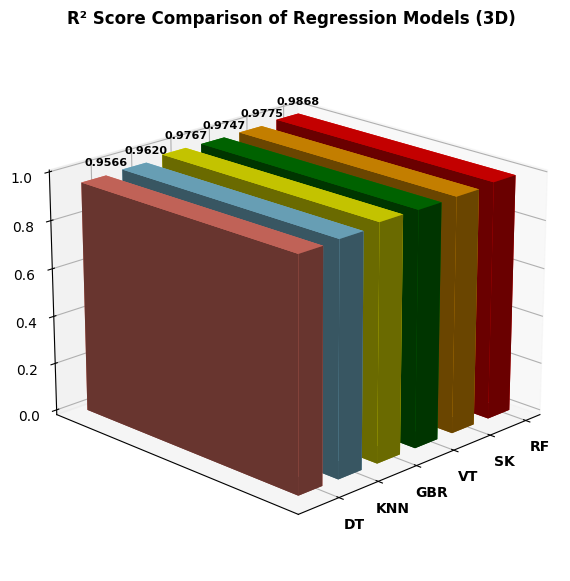

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Regression metrics list (R² scores for different models)
regression_scores = [r2_rf,r2_st,r2_vt,r2_gbr,r2_knn,r2_dt]

# Names of the algorithms
algo_names = ['RF','SK','VT','GBR','KNN','DT',]

# Define colors for each bar
colors = ['red','orange','green','yellow', 'skyblue', 'salmon']

# Create figure and 3D axis
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# X positions for bars
x_pos = np.arange(len(algo_names))
y_pos = np.zeros(len(algo_names))  # Single bar depth

# Bar width and depth
width = 0.6
depth = 0.4

# Create 3D bars
bars = ax.bar3d(x_pos, y_pos, np.zeros(len(algo_names)), width, depth, regression_scores, color=colors, shade=True)

# Set labels and title
ax.set_xticks(x_pos)
ax.set_xticklabels(algo_names, fontsize=10, fontweight='bold')
ax.set_yticks([])  # Hide y-axis ticks
ax.set_zlabel("R² Score", fontsize=10, fontweight='bold')
ax.set_title("R² Score Comparison of Regression Models (3D)", fontsize=12, fontweight='bold')

# Annotate bars with scores
for x, z in zip(x_pos, regression_scores):
    ax.text(x, 0, z + 0.03, f"{z:.4f}", ha='center', va='bottom', fontsize=8, fontweight='bold')

# Adjust viewing angle
ax.view_init(elev=20, azim=45)  # Elevation and rotation for better visibility

# Show the plot
plt.show()


In [81]:
actual=np.array(y_test)
predicted=np.array(prediction_rf)

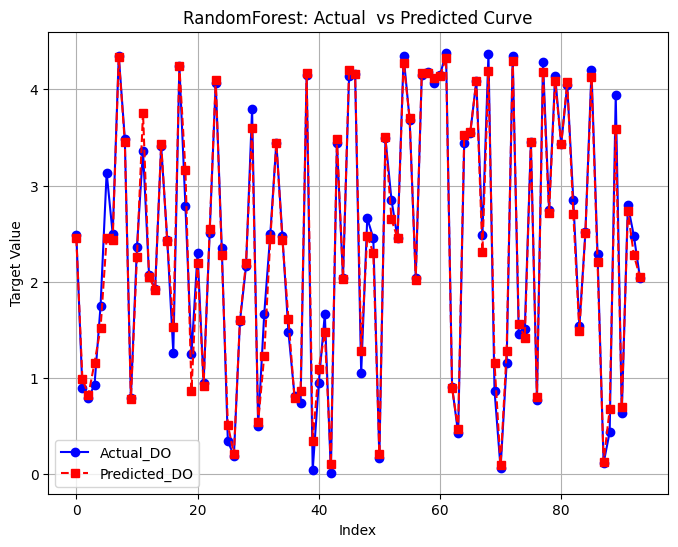

In [82]:
# Plot
plt.figure(figsize=(8, 6))
plt.plot(actual, label="Actual_DO", marker='o', linestyle='-', color='b')
plt.plot(predicted, label="Predicted_DO", marker='s', linestyle='--', color='r')

# Labels and title
plt.xlabel("Index")
plt.ylabel("Target Value")
plt.title("RandomForest: Actual  vs Predicted Curve")
plt.legend()
plt.grid(True)
plt.show()

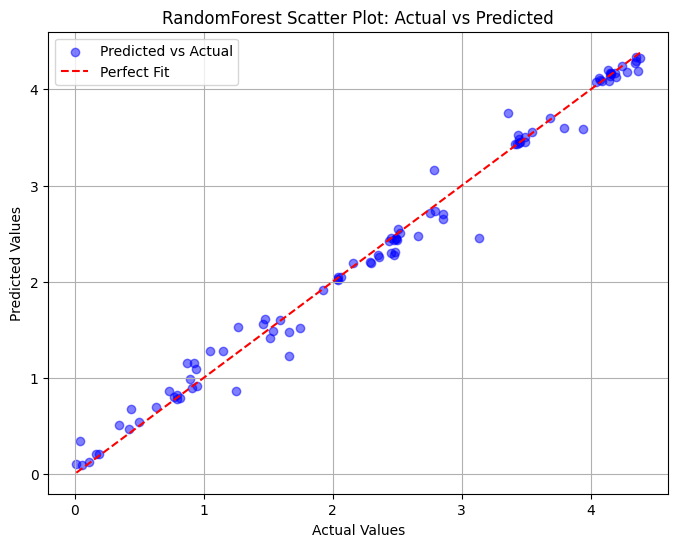

In [83]:
plt.figure(figsize=(8,6))
plt.scatter(actual, predicted, color='blue', alpha=0.5, label="Predicted vs Actual")
plt.plot([min(actual), max(actual)], [min(actual), max(actual)], 'r--', label="Perfect Fit")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("RandomForest Scatter Plot: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


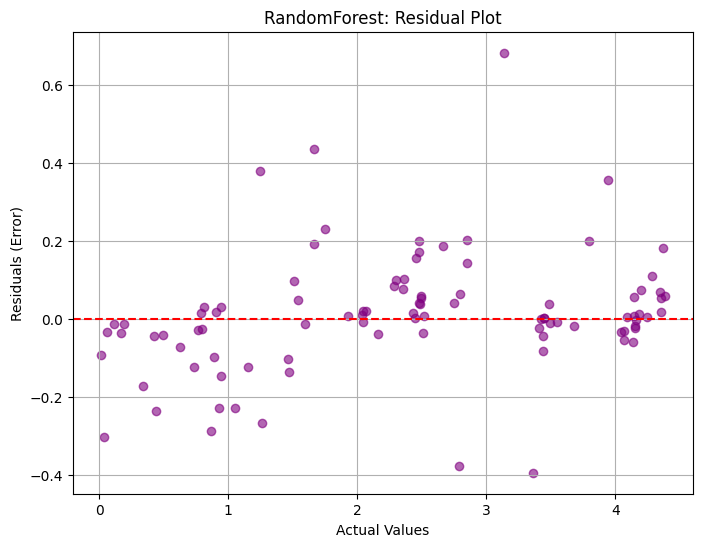

In [84]:
residuals = actual - predicted
plt.figure(figsize=(8,6))
plt.scatter(actual, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Error)")
plt.title("RandomForest: Residual Plot")
plt.grid(True)
plt.show()

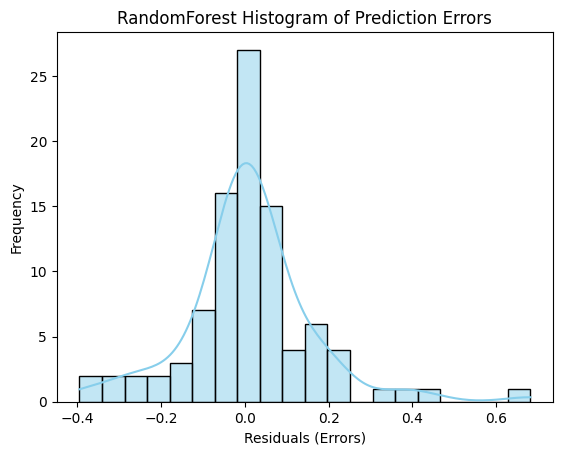

In [86]:
import seaborn as sns

sns.histplot(residuals, kde=True, bins=20, color='skyblue')
plt.xlabel("Residuals (Errors)")
plt.ylabel("Frequency")
plt.title("RandomForest Histogram of Prediction Errors")
plt.show()


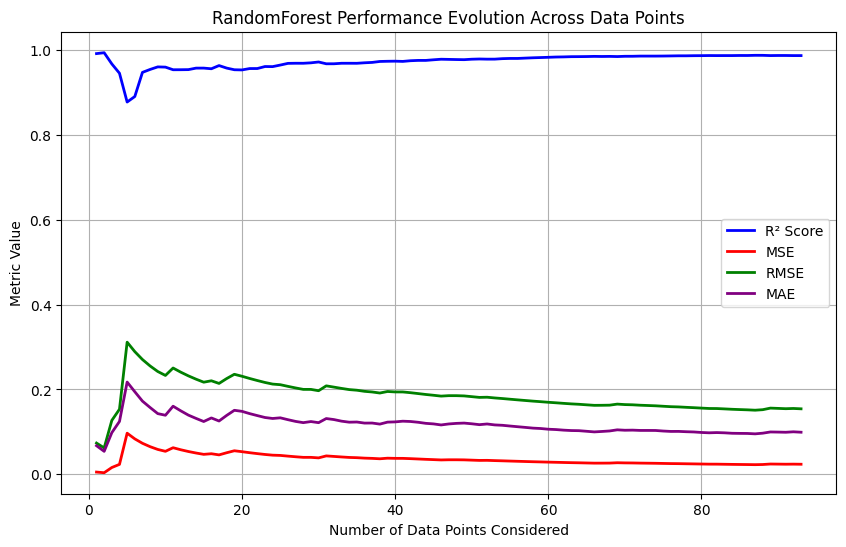

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Initialize lists to store dynamic metrics
r2_scores = []
mse_scores = []
rmse_scores = []
mae_scores = []

# Compute metrics dynamically for each data point
for i in range(1, len(y_test)):
    y_true_subset = y_test[:i+1]
    y_pred_subset = prediction_rf[:i+1]

    r2_scores.append(r2_score(y_true_subset, y_pred_subset))
    mse = mean_squared_error(y_true_subset, y_pred_subset)
    mse_scores.append(mse)
    rmse_scores.append(np.sqrt(mse))
    mae_scores.append(mean_absolute_error(y_true_subset, y_pred_subset))

# Create a figure
plt.figure(figsize=(10, 6))

# Plot R² Score
plt.plot(range(1, len(y_test)), r2_scores, linestyle='-', linewidth=2, color='b', label="R² Score")

# Plot MSE
plt.plot(range(1, len(y_test)), mse_scores, linestyle='-', linewidth=2, color='r', label="MSE")

# Plot RMSE
plt.plot(range(1, len(y_test)), rmse_scores, linestyle='-', linewidth=2, color='g', label="RMSE")

# Plot MAE
plt.plot(range(1, len(y_test)), mae_scores, linestyle='-', linewidth=2, color='purple', label="MAE")

# Labels and title
plt.xlabel("Number of Data Points Considered")
plt.ylabel("Metric Value")
plt.title("RandomForest Performance Evolution Across Data Points")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
la....la....la...la

SyntaxError: invalid syntax (<ipython-input-197-93a72abdc1d6>, line 1)